##Задача

* Найти данные в виде изображений для задачи классификации. Например, можно взять данные [отсюда](http://ufldl.stanford.edu/housenumbers/).
* Реализовать классы, необходимые для построения сети со следующими слоями
  * FullyConnectedLayer
  * ReluLayer
  * FullyConnectedLayer
* Использовать CrossEntropyLoss и L2-регуляризацию.
* Обучить модель на тренировочных данных, подбирать параметры (особенно learning rate) на валидационной и оценить качество на тестовой. Анализировать графики train/val loss, проверять на каждом шаге корректность вычисления градиентов с помощью разностной оценки.
 * (+2 балла) Добавить Batch normalization.
 * (+2 балла) В качестве оптимизатор использовать один из: Momentum, RMSprop.
 * (+1 балл) Также реализовать оптимизатор Adam.

## Датасет
Для задачи классификации возьмем предложенный датасет [The Street View House Numbers (SVHN) Dataset](http://ufldl.stanford.edu/housenumbers/). Каждая картинка 32х32 содержит номер дома, сфотографированный на улице.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

print(torch.__version__)

2.10.0+cpu


**Загрузка датасета SVHN**

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.SVHN(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.SVHN(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

100%|██████████| 182M/182M [00:09<00:00, 19.7MB/s]
100%|██████████| 64.3M/64.3M [00:06<00:00, 10.4MB/s]


**DataLoader**

In [6]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [8]:
images, labels = next(iter(train_loader))
labels = labels % 10
print(images.shape)  # должно быть [64, 3, 32, 32]
print(labels[:10])
print(labels.unique())

torch.Size([64, 3, 32, 32])
tensor([8, 2, 0, 9, 0, 7, 4, 1, 0, 4])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


**Визуализация изображений**

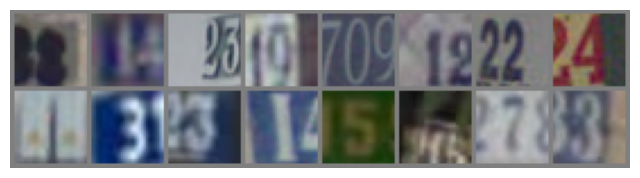

Labels: tensor([8, 1, 2, 9, 0, 1, 2, 4, 1, 3, 3, 1, 5, 1, 7, 3])


In [10]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(images, labels):
    images = images / 2 + 0.5  # денормализация
    npimg = images.numpy()

    plt.figure(figsize=(8, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

images, labels = next(iter(train_loader))
labels = labels % 10

show_batch(torchvision.utils.make_grid(images[:16]), labels[:16])
print("Labels:", labels[:16])

**Train / Validation split**

In [14]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])
train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_data,
    batch_size=64,
    shuffle=False
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)
print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_dataset))

Train: 58605
Val: 14652
Test: 26032


## Построение сети

`W` — веса \
`b` — смещение \
`nn.Parameter` → PyTorch будет считать градиенты \
`@` → матричное умножение

In [17]:
class FullyConnectedLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.W = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.b = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        return x @ self.W.t() + self.b

In [16]:
class ReluLayer(nn.Module):
    def forward(self, x):
        return torch.relu(x)

**Нейронная сеть с batch normalization**

In [19]:
class SimpleNet(nn.Module):
    def __init__(self, use_bn=False):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = FullyConnectedLayer(3*32*32, 256)
        self.bn1 = nn.BatchNorm1d(256) if use_bn else None
        self.relu = ReluLayer()
        self.fc2 = FullyConnectedLayer(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        if self.use_bn:
            x = self.bn1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x